In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils .data import DataLoader
from torchvision import datasets, transforms
from torchvision import models

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    balanced_accuracy_score
)

import pandas as pd
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix


def print_hardest_pairs(
    y_true,y_pred,class_names,top_n=10,save_path=None):
    """
    Find and print the class pairs with the largest bidirectional confusion.
    Bidirectional confusion:
        confusion(i, j) = cm[i, j] + cm[j, i]

    """

    num_classes = len(class_names)

    # Use raw counts rather than the normalised confusion matrix.
    cm = confusion_matrix(
        y_true,y_pred,labels=range(num_classes)
    )

    hardest_pairs = []

    # i < j prevents duplicate pairs:
    # (class A, class B) and (class B, class A)
    for i in range(num_classes):
        for j in range(i + 1, num_classes):
            i_to_j = int(cm[i, j])
            j_to_i = int(cm[j, i])
            total_confusion = i_to_j + j_to_i

            if total_confusion > 0:
                hardest_pairs.append({
                    "Class 1": class_names[i],
                    "Class 2": class_names[j],
                    "Class 1 -> Class 2": i_to_j,
                    "Class 2 -> Class 1": j_to_i,
                    "Bidirectional Total": total_confusion
                })

    hardest_pairs_df = pd.DataFrame(hardest_pairs)

    if hardest_pairs_df.empty:
        print("\nNo inter-class confusion was found.")
        return hardest_pairs_df

    hardest_pairs_df = hardest_pairs_df.sort_values(
        by=["Bidirectional Total","Class 1 -> Class 2","Class 2 -> Class 1"],
        ascending=False).reset_index(drop=True)

    hardest_pairs_df.index += 1
    hardest_pairs_df.index.name = "Rank"

    print(f"\nTop {min(top_n, len(hardest_pairs_df))} hardest class pairs:")
    print(
        hardest_pairs_df.head(top_n).to_string()
    )

    return hardest_pairs_df

In [2]:
def testing(TEST_DIR,MODEL_PATH,model):
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=False
    )

    classes = checkpoint["classes"]
    num_classes = checkpoint["num_classes"]

    print("Number of classes:", num_classes)
    print("Classes:", classes)

    test_transform = transforms.Compose([
        transforms.Resize(
            352,
            interpolation=transforms.InterpolationMode.BILINEAR,
            antialias=True
        ),
        transforms.CenterCrop(320),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    test_dataset = datasets.ImageFolder(
        TEST_DIR,
        transform=test_transform
    )

    assert test_dataset.classes == classes, (
        "different testing set"
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    print("Test images:", len(test_dataset))

    

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    print("Model loaded successfully")

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_probs.append(probs.cpu())
            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    test_accuracy = correct / total

    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Correct predictions: {correct}/{total}")

    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    all_probs = torch.cat(all_probs).numpy()

    top5_accuracy = top_k_accuracy_score(
        y_true, all_probs, k=5, labels=list(range(num_classes))
    )

    macro_precision = precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    balance_accuracy = balanced_accuracy_score(y_true, y_pred)

    print(f"Top-1 Accuracy:    {test_accuracy:.4f}")
    print(f"Top5 Accuracy:    {top5_accuracy:.4f}")
    print(f"Macro Precision:  {macro_precision:.4f}")
    print(f"Macro Recall:     {macro_recall:.4f}")
    print(f"Macro F1:         {macro_f1:.4f}")
    print(f"Weighted F1:      {weighted_f1:.4f}")
    print(f"Balanced Accuracy:      {balance_accuracy:.4f}")

    class_names = test_dataset.classes
    num_classes = len(class_names)

    cm_normalized = confusion_matrix(
        y_true,
        y_pred,
        labels=range(num_classes),
        normalize="true"
    )

    hardest_pairs_df = print_hardest_pairs(y_true=y_true,y_pred=y_pred,
        class_names=class_names,top_n=10,
        save_path="hardest_pairs.csv"
    )

    fig, ax = plt.subplots(figsize=(14, 12))

    sns.heatmap(
        cm_normalized,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=False,
        yticklabels=False,
        ax=ax
    )

    ax.set_title("Normalised Confusion Matrix: ResNet18")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")

    fig.tight_layout()
    plt.show()

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

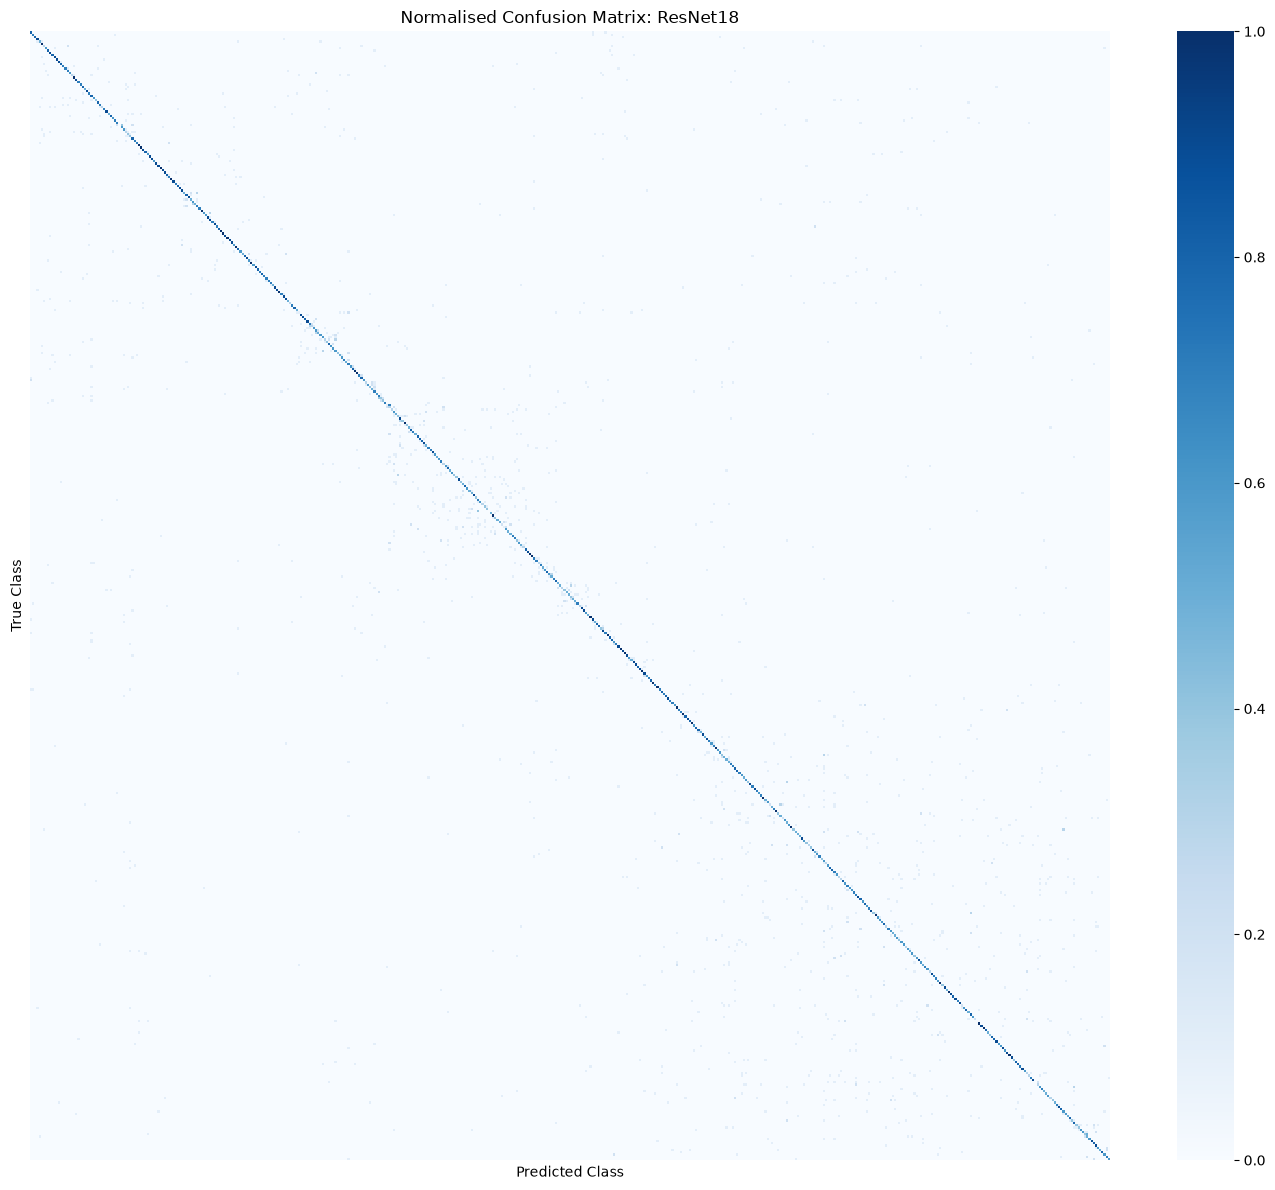

In [5]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_500_ptclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

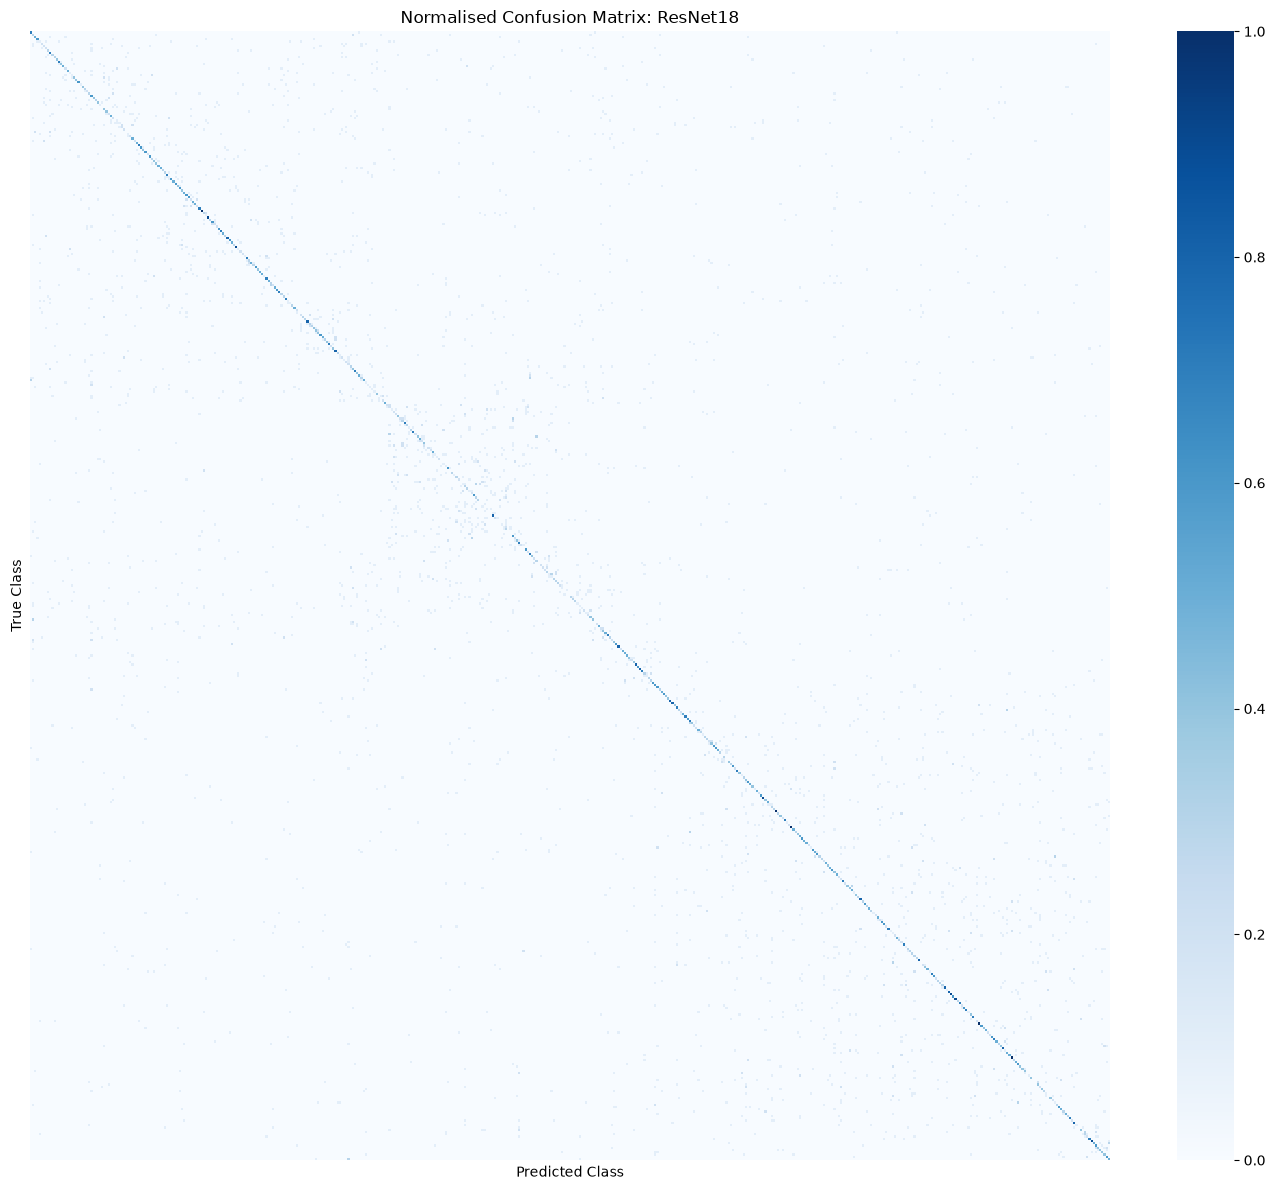

In [6]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_500_npclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

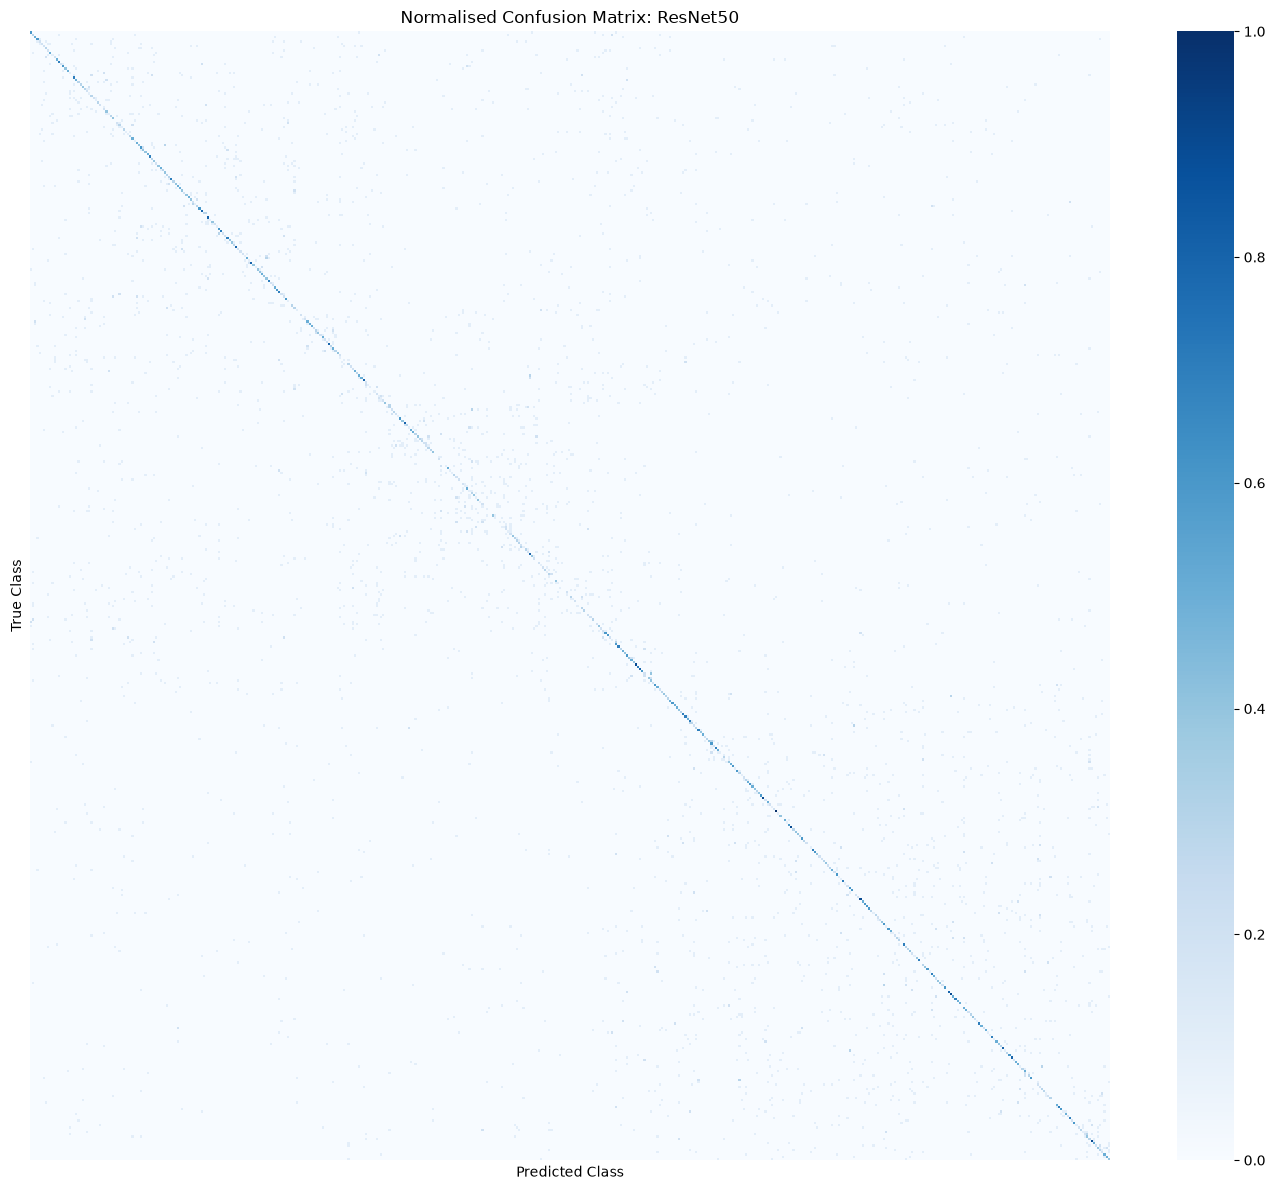

In [12]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_500_npclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

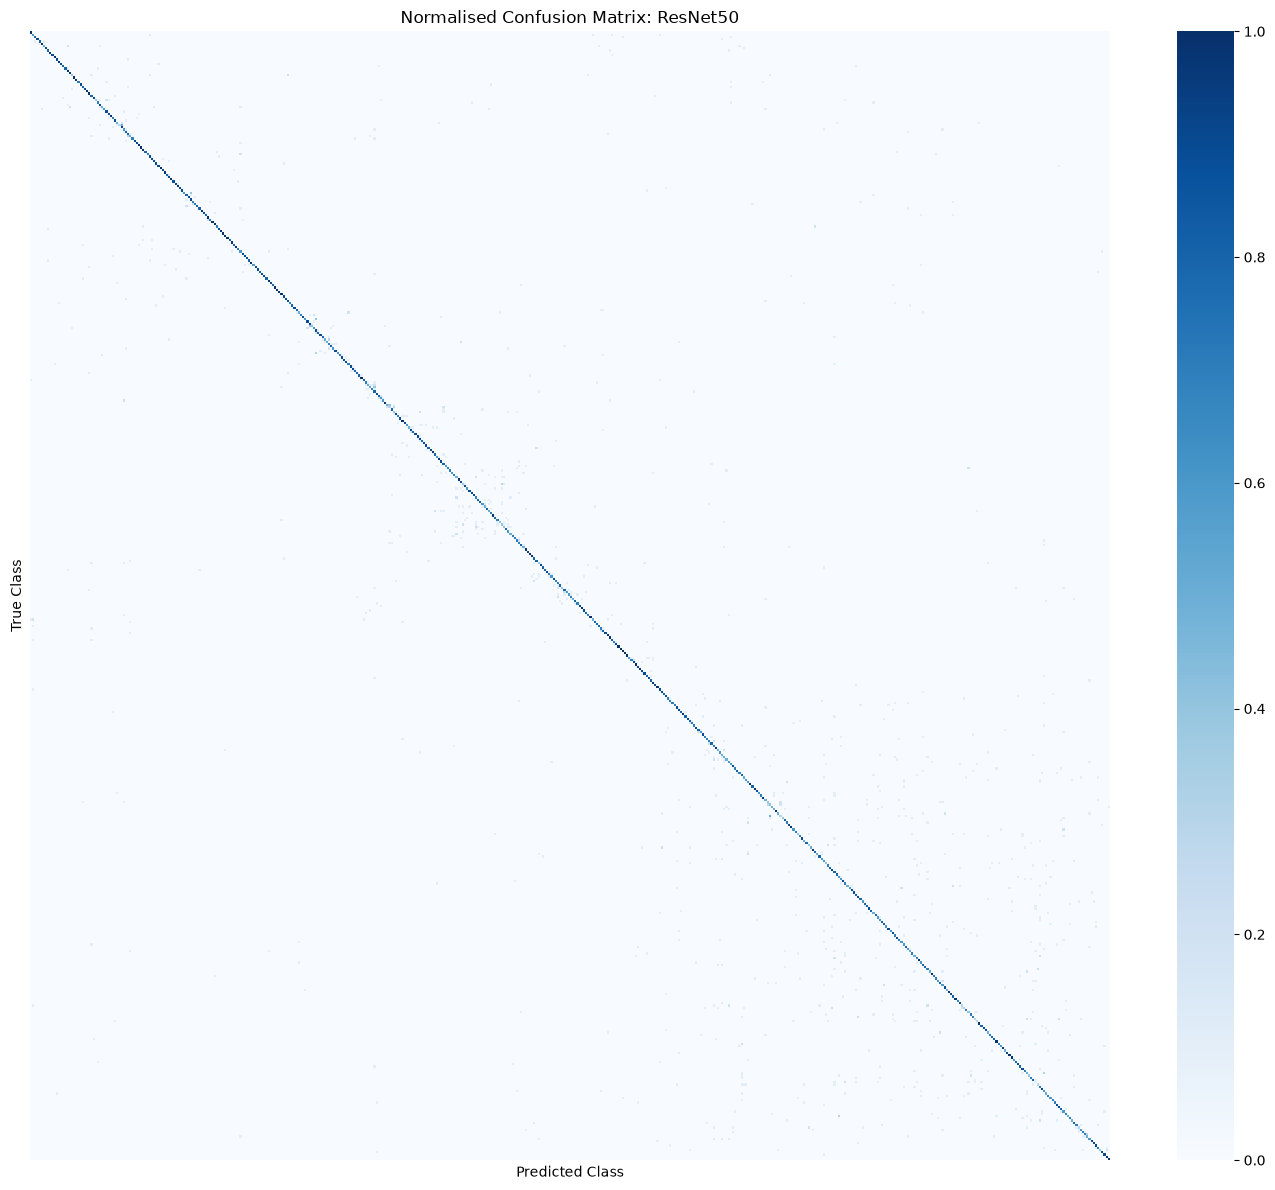

In [13]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_500_ptclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

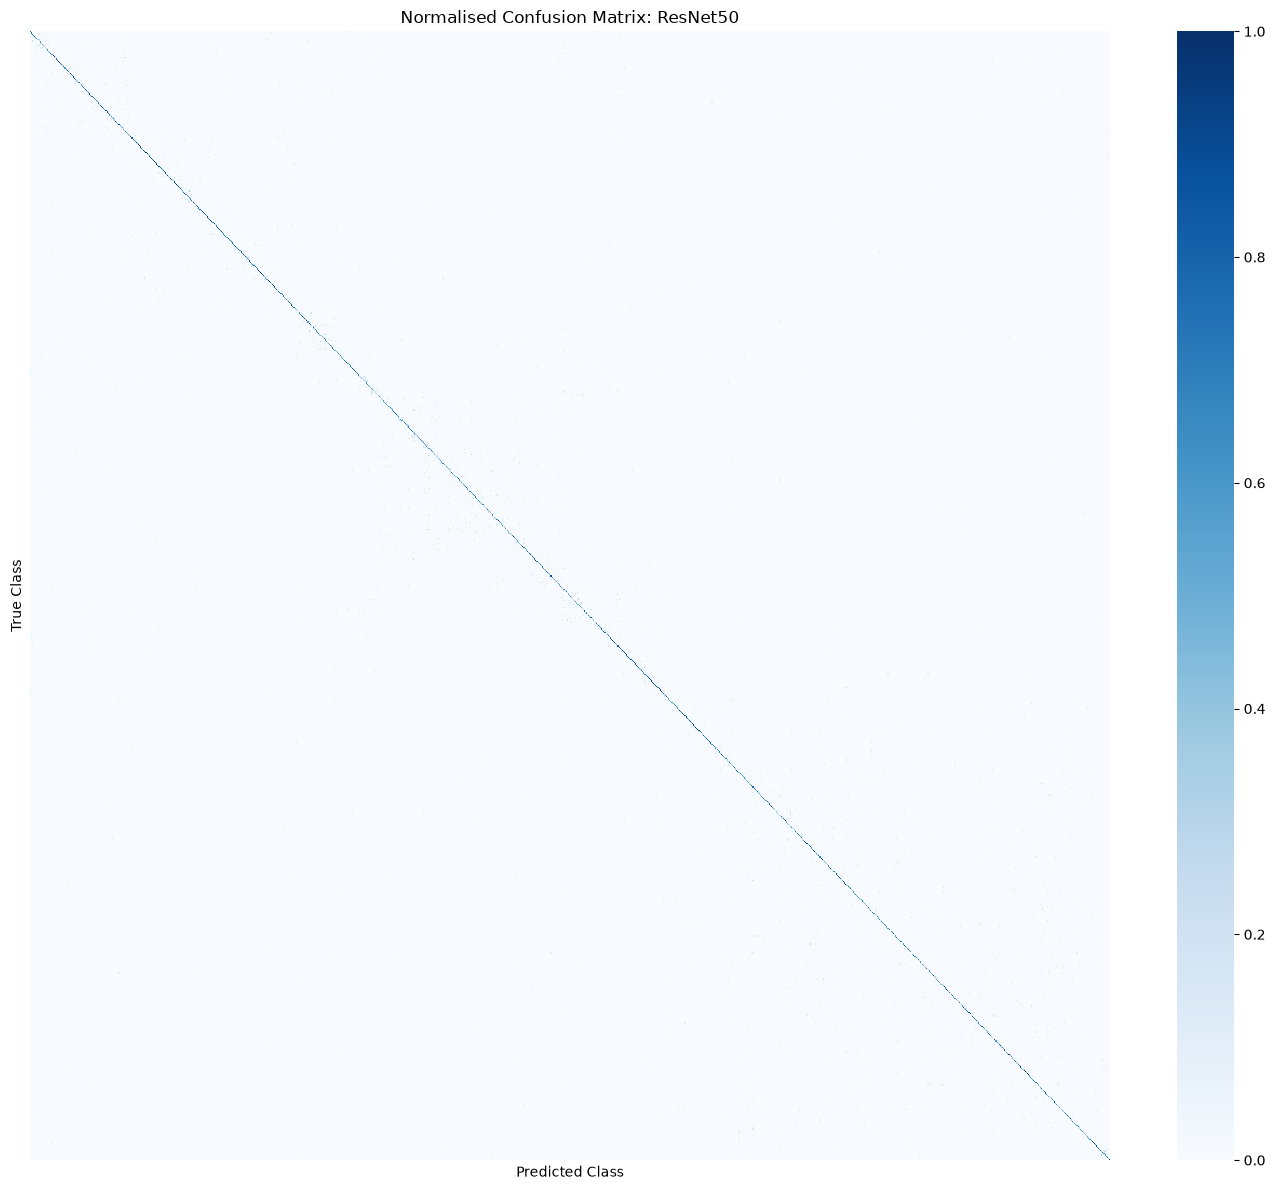

In [14]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_1000_ptclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m29.5s

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

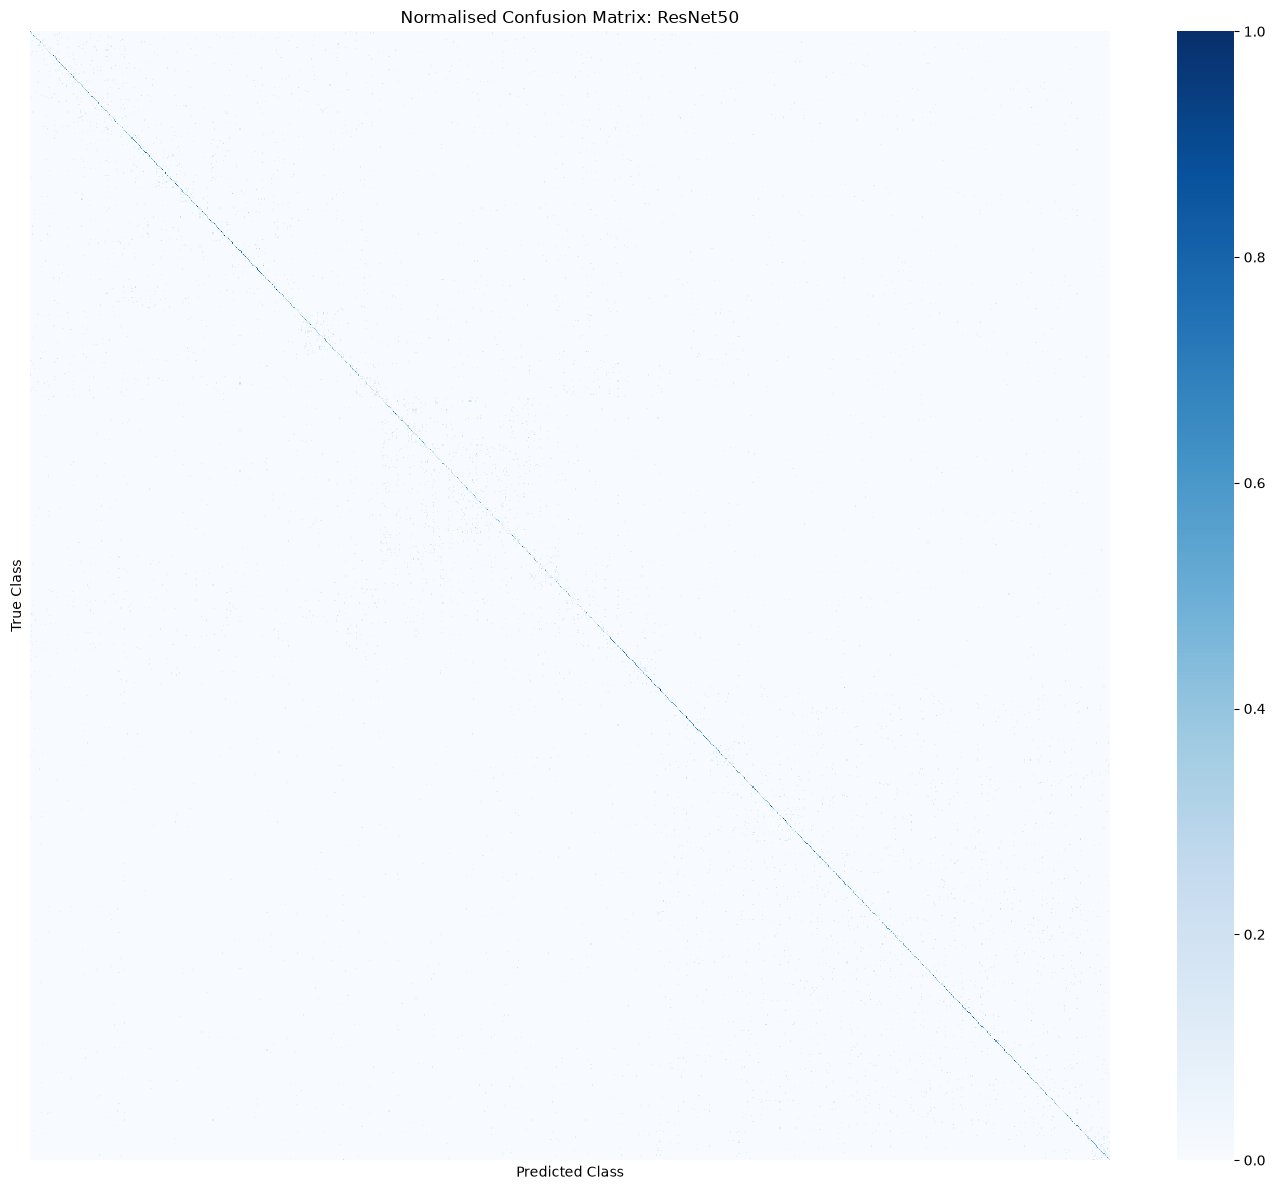

In [15]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet18_1000_npclasses_imagenet.pth"

model = models.resnet18(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m19.1s

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

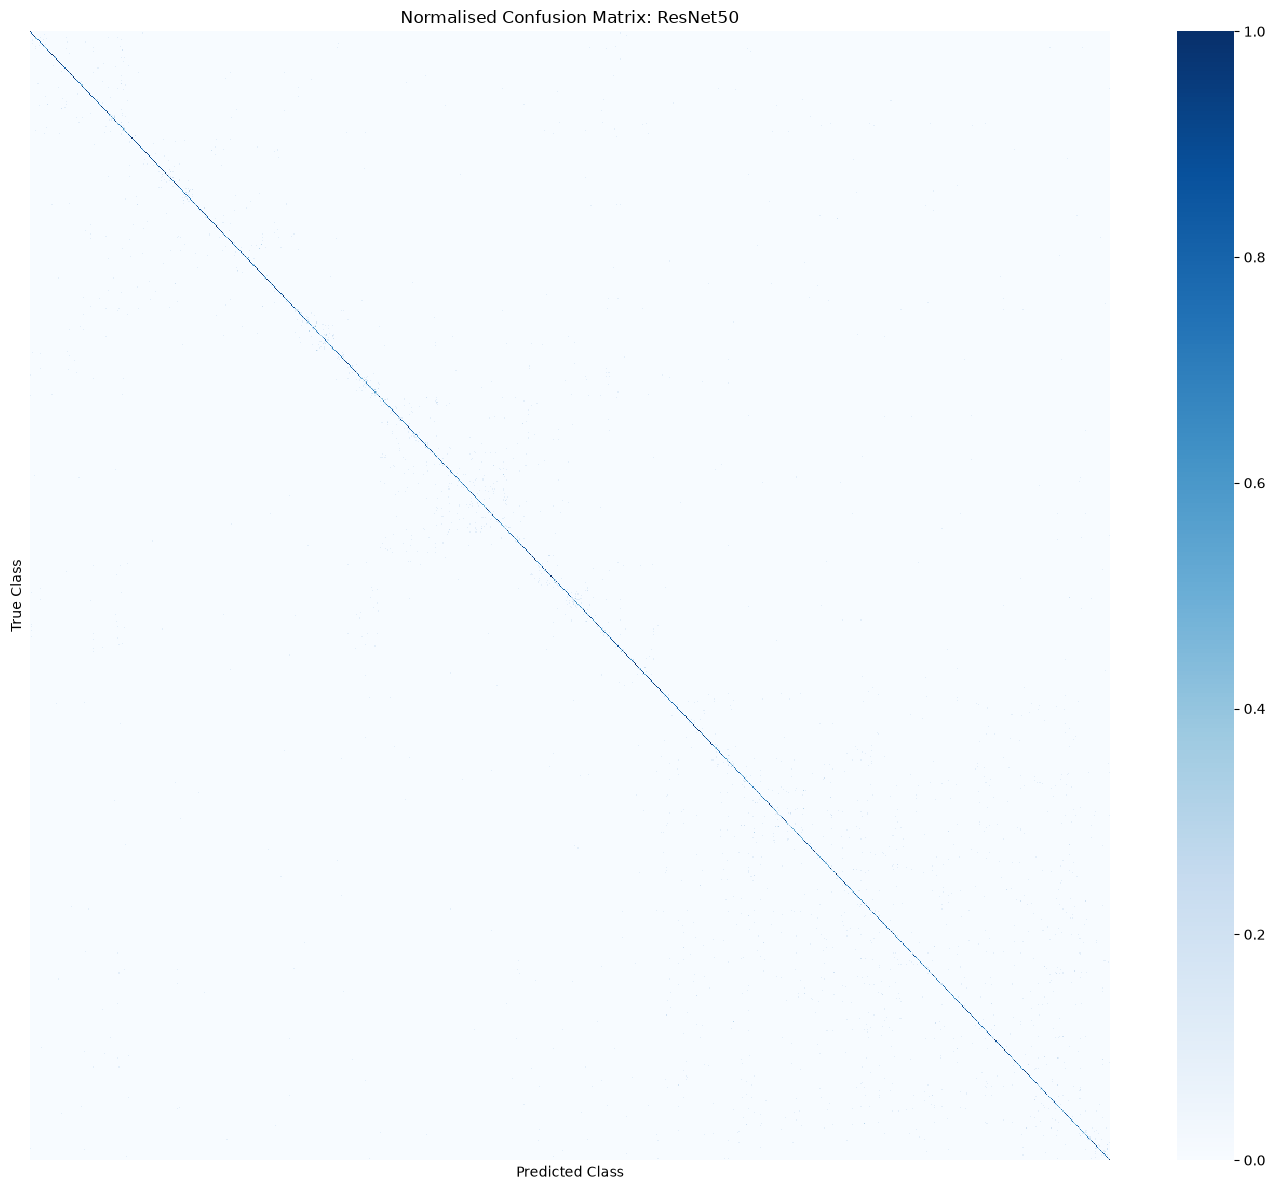

In [16]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_1000_ptclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m29.5s

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

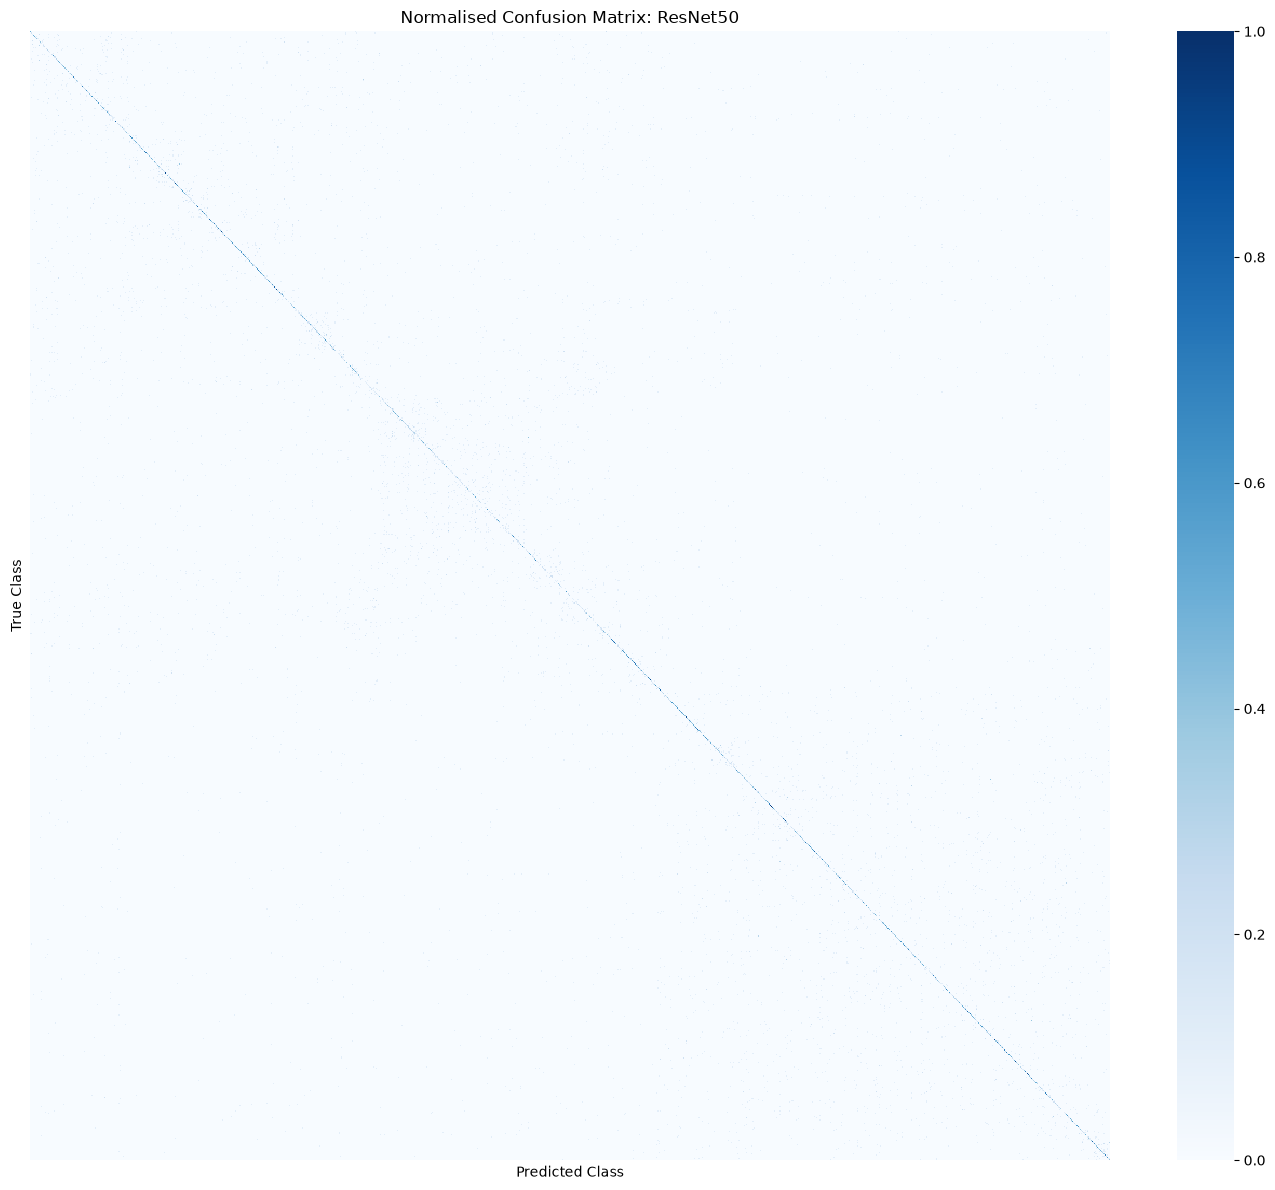

In [17]:
DATA_ROOT = Path(r"D:/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_1000_npclasses_imagenet.pth"

model = models.resnet50(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m45.4s

In [18]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
mp = Path(r"C:\Users\mark\OneDrive\桌面\bk\b")
MODEL_PATH = "inat_alexnet_500_ptclasses_imagenet.pth"

model = models.alexnet(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m45.4s

FileNotFoundError: [Errno 2] No such file or directory: 'inat_alexnet_500_ptclasses_imagenet.pth'

In [ ]:
DATA_ROOT = Path(r"D:/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
mp = Path(r"C:\Users\mark\OneDrive\桌面\bk\b")
MODEL_PATH = "inat_alexnet_500_npclasses_imagenet.pth"

model = models.alexnet(weights=None)

testing(TEST_DIR,MODEL_PATH,model)
#1m45.4s